# *Prominence*: A discriminator of gravitational wave signals
## Companion code for     2509.04384
### To run this notebook you need: scipy, numpy, pandas, tqdm and matplotlib. They can be downloaded using pip. In the first part of the notebook, a few representative plots of the signals and backgrounds are shown, corresponding to Figures 1, 2 and 4 of the paper. 

### Afterwards we show a concrete example for the calculation of the prominence histograms and the computation of the $p-$value. We will demonstrate this for Case (B) of the paper


In [1]:
import scipy
from scipy.integrate import simpson
from scipy.signal import find_peaks, peak_prominences, peak_widths
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
from scipy.special import zeta
from scipy import integrate
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot as plt, ticker as mticker


mpl.rcParams['text.usetex']=True 
mpl.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
plt.rcParams.update({'font.size': 20})
mpl.rcParams["legend.framealpha"] = 1.0
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams["figure.figsize"] = [7.5, 4.5]


In [2]:
# Help function to convert floats into scientfic format in latex
def latex_float(f):
    float_str = "{0:.2g}".format(f)
    if "e" in float_str:
        base, exponent = float_str.split("e")
        return r"{0} \times 10^{{{1}}}".format(base, int(exponent))
    else:
        return float_str


# Load GW-experiment data

In [3]:
# ---- LISA ----
Data_LISA = pd.read_csv('./GW_Data/LISA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_LISA = Data_LISA.loc[Data_LISA['Ompeak'] < 1e-6]
Data_LISA = Data_LISA.sort_values(by=['fpeak'], ascending=True)
LISA_spline = UnivariateSpline(np.log10(Data_LISA['fpeak']), np.log10(Data_LISA['Ompeak']), s=1e-8)

# ---- BBO ----
Data_BBO  = pd.read_csv('./GW_Data/BBO.csv',names = ['fpeak', 'Ompeak'],sep=' ')
Data_BBO = Data_BBO.loc[Data_BBO['Ompeak'] < 1e-6]
Data_BBO = Data_BBO.sort_values(by=['fpeak'], ascending=True)
BB0_spline = UnivariateSpline(np.log10(Data_BBO['fpeak']), np.log10(Data_BBO['Ompeak']), s=1e-8)

# ---- ET ----
Data_ET   = pd.read_csv('./GW_Data/ET.csv',names = ['fpeak', 'Ompeak'],sep=' ')
Data_ET = Data_ET.loc[Data_ET['Ompeak'] < 1e-6]
Data_ET = Data_ET.sort_values(by=['fpeak'], ascending=True)
ET_spline = UnivariateSpline(np.log10(Data_ET['fpeak']), np.log10(Data_ET['Ompeak']), s=1e-8)

# ---- muAres ----
Data_Ares = pd.read_csv('./GW_Data/muAres.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_Ares = Data_Ares.loc[Data_Ares['Ompeak'] < 1e-6]
Data_Ares = Data_Ares.sort_values(by=['fpeak'], ascending=True)
muAres_spline = UnivariateSpline(np.log10(Data_Ares['fpeak']), np.log10(Data_Ares['Ompeak']), s=1e-6)

# ---- LIGO O5 ----
Data_LIGO = pd.read_csv('./GW_Data/HL.csv',names = ['fpeak', 'Ompeak'],sep=' ')
Data_LIGO = Data_LIGO.loc[Data_LIGO['Ompeak'] < 1e-6]
Data_LIGO = Data_LIGO.sort_values(by=['fpeak'], ascending=True)
LIGO_spline = UnivariateSpline(np.log10(Data_LIGO['fpeak']), np.log10(Data_LIGO['Ompeak']), s=1e-8)

# ---- LVK ----
Data_LVK  = pd.read_csv('./GW_Data/LVK.csv',sep=';',decimal=',',header=None)
Data_LVK.rename({0:'fpeak', 1:'Ompeak'},axis=1,inplace=True) 
Data_LVK.drop_duplicates(subset='fpeak', inplace=True)
Data_LVK = Data_LVK.sort_values(by=['fpeak'], ascending=True)
LVK_spline = UnivariateSpline(np.log10(Data_LVK['fpeak']), np.log10(Data_LVK['Ompeak']), s=1e-8)

# ---- SKA ----
Data_SKA   = pd.read_csv('./GW_Data/SKA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_SKA = Data_SKA.loc[Data_SKA['Ompeak'] < 1e-6]
Data_SKA = Data_SKA.sort_values(by=['fpeak'], ascending=True)
SKA_spline = UnivariateSpline(np.log10(Data_SKA['fpeak']), np.log10(Data_SKA['Ompeak']), s=1e-8)

# ---- GAIA ----
Data_GAIA  = pd.read_csv('./GW_Data/GAIA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_GAIA = Data_GAIA.loc[Data_GAIA['Ompeak'] < 1e-6]
Data_GAIA = Data_GAIA.sort_values(by=['fpeak'], ascending=True)
GAIA_spline = UnivariateSpline(np.log10(Data_GAIA['fpeak']), np.log10(Data_GAIA['Ompeak']), s=1e-8)

# ---- THEIA ----
Data_THEIA = pd.read_csv('./GW_Data/THEIA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_THEIA = Data_THEIA.loc[Data_THEIA['Ompeak'] < 1e-6]
Data_THEIA = Data_THEIA.sort_values(by=['fpeak'], ascending=True)
THEIA_spline = UnivariateSpline(np.log10(Data_THEIA['fpeak']), np.log10(Data_THEIA['Ompeak']), s=1e-8)

# ---- NG15 ----
Data_NG15  = pd.read_csv('./GW_Data/NG15.csv',sep=';',decimal=',',header=None,names=['fpeak', 'Ompeak'])



# Functions for GW NP signals and example plots

In [4]:
def hOm_PhaseT(f, gstar, ξw, βH, α, Tp, κsw, κbc):

    # Written based on formulas from LISA Cosmology working group
    # To be made avaible in arxiv sometime soon
    
    # -------------------------------------
    # -------- SOUND WAVE SPECTRUM --------
    # -------------------------------------

    n1_sw, n2_sw, n3_sw, a1_sw, a2_sw = 3, 1, -3, 2, 4
    Γ           = 4/3 # adiabatic index. 4/3 for radiation fluid
    cs          = 1/np.sqrt(3)
    ξshell      = np.abs(ξw - cs)
    Δw          = ξshell/max(ξw, cs)
    Hstar_Rstar = (8*np.pi)**(1/3) * max(ξw, cs) * βH**(-1)
    Trh_V       = Tp #Tp*(1 + α)**(1/4)
    H0star      = (1.65 * 10**(-5)) * (gstar/100) ** (1/6) * (Trh_V/100) # Factor to include redshifting to present day (i.e. already has the h^2 prefactor included)
    FGW0        = (1.64 * 10**(-5)) * (100/gstar)**(1/3)                 # Factor to include redshifting to present day (i.e. already has the h^2 prefactor included)
    Asw         = 0.11
    vJ          = (np.sqrt((2/3)*α + α**2) + np.sqrt(1/3))/ (1 + α)

    K           = (0.6*κsw*α)/(1 + α)
    vfsq        = Γ**(-1)*K
    Hstar_τsh   = Hstar_Rstar/np.sqrt(vfsq)
    Hstar_τstar = min(Hstar_τsh, 1)

    # Spectral shape
    def S_SW(f, args):
        n1,n2,n3,a1,a2,f1,f2 = args
        return (f/f1)**n1 * ( 1 + (f/f1)**a1)**((-n1+n2)/(a1))  * ( 1 + (f/f2)**a2 )**((-n2 + n3)/a2)
        
    f1_sw = 0.2 * H0star * (Hstar_Rstar)**(-1)
    f2_sw = 0.5 * H0star * Δw**(-1) * (Hstar_Rstar)**(-1)
    Ωint  = FGW0 * Asw * K**2 * Hstar_τstar * Hstar_Rstar 

    #Integrate spectral shape to get normalisation factor (use a better f)
    ff1 = np.geomspace(1e-10,1000,100_000)
    Sf1  = S_SW(ff1, [n1_sw,n2_sw,n3_sw,a1_sw,a2_sw,f1_sw,f2_sw] )
    lnf1 = np.log(ff1)
    N   = 1/simpson(Sf1, x=lnf1)
    
    # Sound wave amplitude and its peak
    Sf  = S_SW(f, [n1_sw,n2_sw,n3_sw,a1_sw,a2_sw,f1_sw,f2_sw] )
    ΩSW      = N * Ωint * Sf
    ΩSW_peak = max(ΩSW)

    # -----------------------------------------------
    # ---------- BUBBLE COLLISION SPECTRUM ----------
    # -----------------------------------------------

    n1_bc, n2_bc, a1_bc = 2.4, -2.4, 1.2
    Astr   = 0.05

    Ktilde = κbc*(α/(1 + α))
    Ωp     = FGW0 * Astr * Ktilde**2 * βH**(-2)
    fp     = 0.11 * H0star * βH
    
    # Spectral shape
    def S_BC(f, args):
        n1,n2,a1,fpeak = args
        den  = (n1 - n2)**((n1-n2)/a1)
        num  = ( -n2*(f/fpeak)**(-n1*a1/(n1-n2)) + n1*(f/fpeak)**(-n2*a1/(n1-n2)) )**((n1-n2)/a1)
        return den/num
    
    # Bubble collision amplitude and its peak
    ΩBC      = Ωp * S_BC(f, [n1_bc, n2_bc, a1_bc, fp])
    ΩBC_peak = max(ΩBC)
    
    # Get peak amplitude and frequency from full spectra
    ΩFull      = ΩSW + ΩBC
    Index      = np.where(ΩFull == ΩFull.max())[0][0]
    Ωpeak_full = ΩFull[Index]
    fpeak_full = f[Index]
    
    return {'Ompeak_full':Ωpeak_full, 'Om_full':ΩFull, 'f':f, 'fpeak_full':fpeak_full, 'f_list':f}    

def hOm_DomainWall(f, E, Vbias, b, c):
    
    a         = 3
    eGW       = 0.7 # 0.7±0.4
    gstar     = 106.75 # SM High-T DOFs
    A         = 0.8 # 0.8 ± 0.1/ area parameter
    Cann      = 5 # Assuming Z2 breaking
    hOm_peak  = 1.49e-10 * (eGW/0.7) * (A/0.8)**4 * (10.75/gstar)**(1/3) * (E**(1/3)/1e7)**(12) * (1e7/Vbias)**2
    f_peak    = 5.93e-6 * (5/Cann)**(1/2)*(0.8/A)**(1/2)*(1e7/E**(1/3))**(3/2)*(Vbias/1e7)**(1/2)
    S         = lambda x: ((a+b)**c)/(b*x**(-a/c) + a*x**(b/c))**c
    hOm_Total = hOm_peak*S(f/f_peak)
    
    return hOm_Total

def hOm_CosmicString(f, G_mu, C, match_feq):

    # Analytical formulas from 2312.10455
    
    fyr            = 32*1e-9
    Gamma          = 50
    u_k            = lambda k: (2.89/(2*k))*(f/fyr)*(Gamma/50)*(G_mu/1e-11)
    Sum_k1         = sum( (1/((1 + 2.075*u_k(k))**(1.945))) * ( k**(-17/6)/zeta(17/6) ) for k in range(1,25)  ) 

    hOm_PTA_PowerL = 4.2e-9 * (f/fyr)**(3/2) * (Gamma/50) * (G_mu/(1e-11))**2 * 1
    hOm_PTA        = hOm_PTA_PowerL * Sum_k1
    hOm_Total      = hOm_PTA
        
    if (f > match_feq):
        hOm_Laser = 4.78e-5*C*np.sqrt(G_mu)
        hOm_Total += hOm_Laser

    return hOm_Total

def hOm_PhaseInf(f, logA, logfc, alpha, beta):    
    A  = 10**logA
    fc = 10**logfc
    
    return A*(alpha + beta)/(beta*(f/fc)**(-alpha) + alpha*(f/fc)**beta)


In [5]:
f_sig    = np.geomspace(1e-15,1000,15_000)

# Domain wall signal (central curve)
eGW      = 0.7    # 0.7±0.4
gstar    = 106.75 # SM High-T DOFs
A        = 0.8    # 0.8 ± 0.1/ area parameter
Cann     = 5      # Assuming Z2 breaking

Om_peakDW = 1e-9
f_peakDW  = 1e-4
E_DW      = (2.0992543946221914e35*Cann*f_peakDW**2*np.sqrt(Om_peakDW))/(A*np.sqrt(eGW)*(1/gstar)**0.16666666666666666)
Vbias_DW  = (1.4924359194979877e31*Cann**2*f_peakDW**4*np.sqrt(Om_peakDW))/(np.sqrt(eGW)*(1/gstar)**0.16666666666666666)
Om_DW     = hOm_DomainWall(f_sig, E=E_DW, Vbias=Vbias_DW, b=0.75, c=1.65)


# Domain wall grey band (varying b = [0.5,1] and c = [0.3.3])
Om_DW_list_scan = []
N_iter          = 1_000

for i in range(int(N_iter)):
    
    #First peak fixed f = 10^(-5).
    E_DW       = (2.0992543946221914e35*Cann*f_peakDW**2*np.sqrt(Om_peakDW))/(A*np.sqrt(eGW)*(1/gstar)**0.16666666666666666)
    Vbias_DW   = (1.4924359194979877e31*Cann**2*f_peakDW**4*np.sqrt(Om_peakDW))/(np.sqrt(eGW)*(1/gstar)**0.16666666666666666)
    Om_DW_vary = hOm_DomainWall(f_sig, E=E_DW, Vbias=Vbias_DW, b=np.random.uniform(0.5,1),c=np.random.uniform(0.3,3))
    Om_DW_list_scan.append(Om_DW_vary)


# Cosmic string signal
# First, determine frequency where to match PTA/inter expressions
def func(x, a, c, d):
    return a*10**(-c*x) + d

freq_r = np.array([1, 1e-1, 1e-2, 1e-3, 1e-4])
gmu_r  = np.array([1e-17, 1e-16, 1e-15, 1e-14, 1e-13])
logx   = np.log(freq_r)
logy   = np.log(gmu_r)
coeffs = np.polyfit(logx,logy,deg=3)
poly   = np.poly1d(coeffs)
yfit   = lambda x: np.exp(poly(np.log(x)))

G_mu  = 1e-11
Om_CS = np.array([hOm_CosmicString(f1, G_mu, 0.8, match_feq=0.1*yfit(G_mu)) for f1 in f_sig])


# Scalar-induced signal
logA     = -7.32
logfc    = -6.59
alphaInf = 1.21
betaInf  = 2.78
Om_SIGW  = hOm_PhaseInf(f_sig, logA, logfc, alphaInf, betaInf)


# FOPT signal
Om_PT = hOm_PhaseT(f=f_sig, gstar=106.75, ξw=1, βH=50, α=1.64, Tp=37.81, κsw=1, κbc=0)['Om_full']


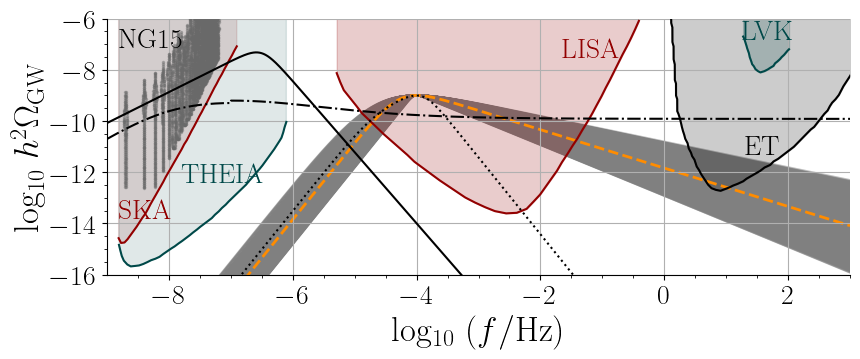

In [6]:
fig, axs = plt.subplots(1, 1, figsize=(9, 4), tight_layout=True)

##### Interferometer experiments
f_expInt  = [np.log10(Data_LISA['fpeak']),np.log10(Data_ET['fpeak']),np.log10(Data_LVK['fpeak'])]
Om_expInt = [np.log10(Data_LISA['Ompeak']),np.log10(Data_ET['Ompeak']),np.log10(Data_LVK['Ompeak'])]
labels    = [r'$\mathrm{LISA}$',r'$\mathrm{ET}$',r'$\mathrm{LVK}$']
colors    = ['#920000','black','#004949']

for a in zip(f_expInt,Om_expInt,labels,colors):
    plt.plot(a[0], a[1], label=a[2], color=a[3], rasterized=True)
    plt.fill_between(a[0], a[1], 1e-4*np.ones(len(a[0])), alpha=0.2, color=a[3], rasterized=True)

##### PTA experiments
f_expPTA  = [np.log10(Data_SKA['fpeak']),np.log10(Data_THEIA['fpeak'])]
Om_expPTA = [np.log10(Data_SKA['Ompeak']),np.log10(Data_THEIA['Ompeak'])] 
labels    = [r'$\mathrm{SKA}$', r'$\mathrm{THEIA}$']
colors    = ['#920000', '#004949']

for a in zip(f_expPTA,Om_expPTA,labels,colors):
    plt.plot(a[0], a[1], label=a[2], color=a[3], rasterized=True)
    plt.fill_between(a[0], a[1], 1e-4*np.ones(len(a[0])), alpha=0.12, color=a[3], rasterized=True)

##### NG15 periodogram
x1 = np.log10(Data_NG15['fpeak'][0:124])
y1 = np.log10(Data_NG15['Ompeak'][0:124])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][124:258])
y1 = np.log10(Data_NG15['Ompeak'][124:258])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][258:400])
y1 = np.log10(Data_NG15['Ompeak'][258:400])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][400:543])
y1 = np.log10(Data_NG15['Ompeak'][400:543])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][543:678])
y1 = np.log10(Data_NG15['Ompeak'][543:678])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][678:-1])
y1 = np.log10(Data_NG15['Ompeak'][678:-1])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

##### Experiment labels
plt.text(x=-8.8,  y=-13.8, s=r"$\mathrm{SKA}$",   color='#920000')
plt.text(x=-7.8,  y=-12.4, s=r"$\mathrm{THEIA}$", color='#004949')
plt.text(x=-8.80, y=-7.10, s=r"$\mathrm{NG15}$",  color='black')
plt.text(x=-1.65, y=-7.5,  s=r"$\mathrm{LISA}$",  color='#920000')
plt.text(x=1.3,   y=-11.3, s=r"$\mathrm{ET}$",    color='black')
plt.text(x=1.25,  y=-6.8,  s=r"$\mathrm{LVK}$",   color='#004949')

##### GW curves
for i in range(len(Om_DW_list_scan)):
    plt.plot(np.log10(f_sig),np.log10(Om_DW_list_scan[i]),'-',alpha=0.5, color='grey',rasterized=True, zorder=-1)
plt.plot(np.log10(f_sig), np.log10(Om_PT),   linestyle=':',  color='black',      alpha=1, zorder=2)
plt.plot(np.log10(f_sig), np.log10(Om_CS),   linestyle='-.', color='black',      alpha=1)
plt.plot(np.log10(f_sig), np.log10(Om_SIGW), linestyle='-',  color='black',      alpha=1)
plt.plot(np.log10(f_sig), np.log10(Om_DW),   linestyle='--', color='darkorange', alpha=1, zorder=1,linewidth=2)


##### Axis limits
plt.ylim(np.log10(1e-16), np.log10(1e-6))
plt.xlim(np.log10(1e-9), np.log10(1000))

##### Extra ticks for x and y axis
axs.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
axs.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
axs.set_yticks([-16,-14,-12,-10,-8,-6])

##### Axis labels
plt.xlabel(r'$\mathrm{log_{10}}~(f/\mathrm{Hz})$',fontsize=25)
plt.ylabel(r'$\mathrm{log_{10}}~h^2 \Omega_\mathrm{GW}$',fontsize=25)

##### Grid
plt.grid()

plt.tight_layout()
plt.savefig('./Plots/Signals_together.pdf',dpi=125.)



# Functions for astrophysical backgrounds and example plots

In [7]:
def hOm_ExtGW(f, log10_h2Ext, alpha):
    
    hOmExt = 10**log10_h2Ext
    
    return hOmExt*(f/(1e-3))**(alpha)

def hOm_GalGW(f, log10_h2Gal, ns):
    
    Tobs   = 4
    year   = 1
    a1     = -0.15
    b1     = -2.72
    ak     = -0.37
    bk     = -2.49
    v      = 1.56
    f2     = 6.7e-4
    hOmGal = 10**(log10_h2Gal)
    f1     = 10**( a1*np.log10(Tobs/year) + b1 )
    fknee  = 10**( ak*np.log10(Tobs/year) + bk )
    hOm    = (f**3/2)*(f/1)**(-ns)*(1 + np.tanh( (fknee - f)/f2 ) )*np.exp( -(f/f1)**v )*hOmGal
    
    return hOm

def hOm_SMBHBs(f, gw_bhb):

    # Values used by PTArcade/Nanograv collab.
    Tspan  = 505861299.1401643
    fyr    = 3.168808781402895e-08
    H_0_Hz = 2.1842852410855023e-18
    h      = 0.674
    
    h2Omega = (2*np.pi**2*(10**gw_bhb[0])**2)/(3*H_0_Hz**2) * \
              (f/(fyr**(1)))**(5-gw_bhb[1]) * (fyr**(2))

    return h2Omega


In [8]:
# Background spectrum (central values for parameters)
log10_h2Ext  = -12.38
log10_h2Gal  = -7.85   
alphaExt     = 0.66 
alphaGal     = 7/3 

f_back  = np.geomspace(1e-15,1000,15_000)
Om_Gal  = hOm_GalGW(f_back,log10_h2Gal,alphaGal) # Galactic
Om_EGal = hOm_ExtGW(f_back,log10_h2Ext,alphaExt) # Ext-Galactic
Om_bgd  = Om_Gal + Om_EGal                       # Sum (Galactic + Ext-Galactic)
Om_PTA  = hOm_SMBHBs(f_back, [-15.6, 4.7])       # PTA region. black-hole binaries


/home/mrazi09/anaconda3/envs/GravWaves/lib/python3.7/site-packages/ipykernel_launcher.py:64: RuntimeWarning: divide by zero encountered in log10


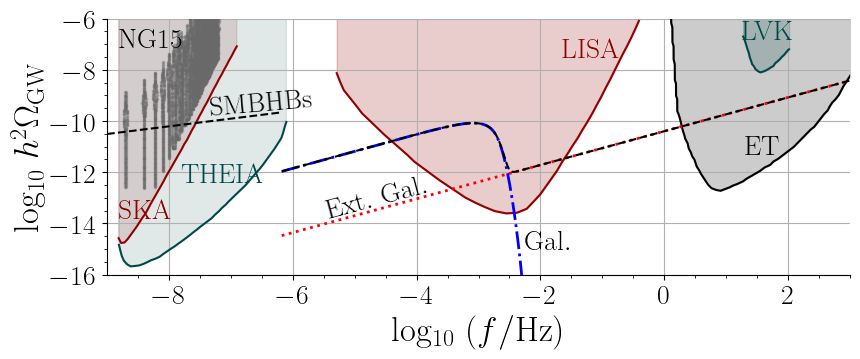

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(9, 4), tight_layout=True)

##### Interferometer experiments
f_expInt  = [np.log10(Data_LISA['fpeak']),np.log10(Data_ET['fpeak']),np.log10(Data_LVK['fpeak'])]
Om_expInt = [np.log10(Data_LISA['Ompeak']),np.log10(Data_ET['Ompeak']),np.log10(Data_LVK['Ompeak'])]
labels    = [r'$\mathrm{LISA}$',r'$\mathrm{ET}$',r'$\mathrm{LVK}$']
colors    = ['#920000','black','#004949']

for a in zip(f_expInt,Om_expInt,labels,colors):
    plt.plot(a[0], a[1], label=a[2], color=a[3], rasterized=True)
    plt.fill_between(a[0], a[1], 1e-4*np.ones(len(a[0])), alpha=0.2, color=a[3], rasterized=True)

##### PTA experiments
f_expPTA  = [np.log10(Data_SKA['fpeak']),np.log10(Data_THEIA['fpeak'])]
Om_expPTA = [np.log10(Data_SKA['Ompeak']),np.log10(Data_THEIA['Ompeak'])] 
labels    = [r'$\mathrm{SKA}$', r'$\mathrm{THEIA}$']
colors    = ['#920000', '#004949']

for a in zip(f_expPTA,Om_expPTA,labels,colors):
    plt.plot(a[0], a[1], label=a[2], color=a[3], rasterized=True)
    plt.fill_between(a[0], a[1], 1e-4*np.ones(len(a[0])), alpha=0.12, color=a[3], rasterized=True)

##### NG15 periodogram
x1 = np.log10(Data_NG15['fpeak'][0:124])
y1 = np.log10(Data_NG15['Ompeak'][0:124])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][124:258])
y1 = np.log10(Data_NG15['Ompeak'][124:258])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][258:400])
y1 = np.log10(Data_NG15['Ompeak'][258:400])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][400:543])
y1 = np.log10(Data_NG15['Ompeak'][400:543])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][543:678])
y1 = np.log10(Data_NG15['Ompeak'][543:678])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

x1 = np.log10(Data_NG15['fpeak'][678:-1])
y1 = np.log10(Data_NG15['Ompeak'][678:-1])
plt.plot(x1,y1,'.',color='dimgray',alpha=0.40,markersize=3)

##### Experiment labels
plt.text(x=-8.8,  y=-13.8, s=r"$\mathrm{SKA}$",   color='#920000')
plt.text(x=-7.8,  y=-12.4, s=r"$\mathrm{THEIA}$", color='#004949')
plt.text(x=-8.80, y=-7.10, s=r"$\mathrm{NG15}$",  color='black')
plt.text(x=-1.65, y=-7.5,  s=r"$\mathrm{LISA}$",  color='#920000')
plt.text(x=1.3,   y=-11.3, s=r"$\mathrm{ET}$",    color='black')
plt.text(x=1.25,  y=-6.8,  s=r"$\mathrm{LVK}$",   color='#004949')

##### Background labels
plt.text(x=-7.35,y=-9.75,s=r'$\mathrm{SMBHBs}$',rotation=5)
plt.text(x=-5.5,y=-13.8,s=r'$\mathrm{Ext.~Gal.}$',rotation=15)
plt.text(x=-2.25,y=-15.0,s=r'$\mathrm{Gal.}$',rotation=0)

##### GW curves
plt.plot(np.log10(f_back)[0:7_350],  np.log10(Om_PTA)[0:7_350],   '--k'             ) # Plot only within PTA frequencies
plt.plot(np.log10(f_back)[7_350:-1], np.log10(Om_EGal)[7_350:-1], ':r',  linewidth=2) # Plot for high freqs.
plt.plot(np.log10(f_back)[7_350:-1], np.log10(Om_Gal)[7_350:-1],  '-.b', linewidth=2) # Plot for high freqs.
plt.plot(np.log10(f_back)[7_350:-1], np.log10(Om_bgd)[7_350:-1],  '--k'             ) # Plot for high freqs.

##### Axis limits
plt.ylim(np.log10(1e-16), np.log10(1e-6))
plt.xlim(np.log10(1e-9), np.log10(1000))

##### Extra ticks for x and y axis
axs.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
axs.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
axs.set_yticks([-16,-14,-12,-10,-8,-6])

##### Axis labels
plt.xlabel(r'$\mathrm{log_{10}}~(f/\mathrm{Hz})$',fontsize=25)
plt.ylabel(r'$\mathrm{log_{10}}~h^2 \Omega_\mathrm{GW}$',fontsize=25)

##### Grid
plt.grid()

plt.tight_layout()
plt.savefig('./Plots/Background_together.pdf',dpi=125.)



# *Prominence* example

In [10]:
# Frequency range sets the window where prominence gets calculated
# Changing the window, changes the prominence !!!
f_window = np.geomspace(1e-7, 1000, 5_000) 

# Fake signal example
Om_Full = np.log10(
                hOm_PhaseT(f=f_window, gstar=106.75, ξw=0.3, βH=1, α=0.05, Tp=8,   κsw=1,   κbc=0)['Om_full'] + \
                hOm_PhaseT(f=f_window, gstar=106.75, ξw=1,   βH=1, α=2.5,  Tp=1e4, κsw=1,   κbc=0)['Om_full'] + \
                hOm_PhaseT(f=f_window, gstar=106.75, ξw=1,   βH=1, α=0.05, Tp=3e6, κsw=1,   κbc=0)['Om_full'] + \
                hOm_PhaseT(f=f_window, gstar=106.75, ξw=1,   βH=1, α=1,    Tp=7e9, κsw=0.2, κbc=0.8)['Om_full']
                 ) 

##### Prominence calculation
peaks, _        = find_peaks(Om_Full, distance=1)     # Find peaks
prominences     = peak_prominences(Om_Full, peaks)[0] # Get prominences of each peak
contour_heights = Om_Full[peaks] - prominences        # prominence base (line between valleys)


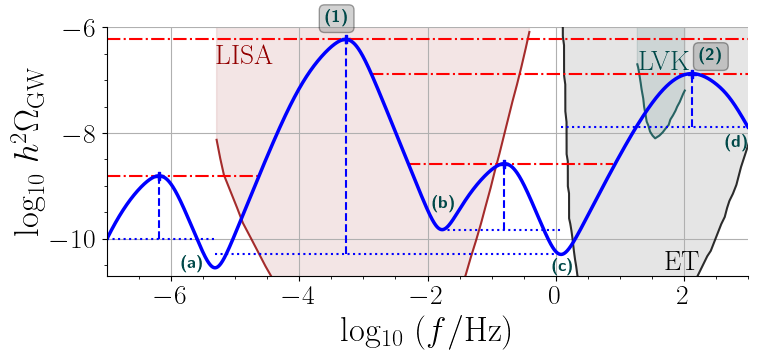

In [11]:
fig, axs = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)

##### Interferometer experiments
fpeak  = [np.log10(Data_LISA['fpeak']), np.log10(Data_ET['fpeak']), np.log10(Data_LVK['fpeak'])]
Ompeak = [np.log10(Data_LISA['Ompeak']), np.log10(Data_ET['Ompeak']), np.log10(Data_LVK['Ompeak'])]
labels = [r'$\mathrm{LISA}$',r'$\mathrm{ET}$',r'$\mathrm{LVK}$']
colors = ['#920000','black','#004949']

for a in zip(fpeak,Ompeak,labels,colors):
    axs.plot(a[0], a[1], '-',label=a[2], color=a[3], rasterized=True, alpha=0.8)
    axs.fill_between(a[0], a[1], 1e-4*np.ones(len(a[0])), alpha=0.1, color=a[3], rasterized=True)

axs.text(x=-5.3,y=-6.7,s=r"$\mathrm{LISA}$",color='#920000')
axs.text(x=1.7,y=-10.6,s=r"$\mathrm{ET}$",color='black')
axs.text(x=1.3,y=-6.8,s=r"$\mathrm{LVK}$",color='#004949')

##### Prominence plotting: peaks->scatter, prominence bases->hline and prominence->vline
plt.scatter(np.log10(f_window)[peaks],Om_Full[peaks],marker='P',color='blue') 
plt.vlines(x=np.log10(f_window)[peaks], ymin=contour_heights, ymax=Om_Full[peaks],color='blue',linestyle='dashed',zorder=100)
plt.hlines(y=contour_heights,xmin=np.log10(f_window)[peak_prominences(Om_Full, peaks)[1]], xmax=np.log10(f_window)[peak_prominences(Om_Full, peaks)[2]], color='blue',linestyle=':', alpha=1,linewidth=1.5)    

#Prominence lines
plt.hlines(y=Om_Full[peaks][0], xmin=-7,    xmax=-4.65, color='red', linestyle='-.', alpha=1, linewidth=1.5)
plt.hlines(y=Om_Full[peaks][1], xmin=-7,    xmax=3,     color='red', linestyle='-.', alpha=1, linewidth=1.5)    
plt.hlines(y=Om_Full[peaks][2], xmin=-2.32, xmax=0.9,   color='red', linestyle='-.', alpha=1, linewidth=1.5)
plt.hlines(y=Om_Full[peaks][3], xmin=-2.9,  xmax=3,     color='red', linestyle='-.', alpha=1, linewidth=1.5)

##### GW curve
axs.plot(np.log10(f_window), Om_Full ,'-', color='blue',linewidth=2.5)

##### Labels
props = dict(boxstyle='round', facecolor='gray', alpha=0.35)
axs.text(x=np.log10(f_window)[peaks[0]]*0.945,y=Om_Full[peaks[0]]*1.2 ,s=r"$\mathrm{\textbf{(a)}}$",color='#004949', fontsize=12.5)
axs.text(x=np.log10(f_window)[peaks[0]]*0.312,y=Om_Full[peaks[0]]*1.07 ,s=r"$\mathrm{\textbf{(b)}}$",color='#004949', fontsize=12.5)
axs.text(x=np.log10(f_window)[peaks[0]]*0.010,y=Om_Full[peaks[0]]*1.205 ,s=r"$\mathrm{\textbf{(c)}}$",color='#004949', fontsize=12.5)
axs.text(x=2.65,y=Om_Full[peaks[0]]*0.94,s=r"$\mathrm{\textbf{(d)}}$",color='#004949', fontsize=12.5)
axs.text(x=np.log10(f_window)[peaks[1]]*1.1,y=Om_Full[peaks[1]]*0.95 ,s=r"$\mathrm{\textbf{(1)}}$",color='#004949',bbox=props, fontsize=12.5)
axs.text(x=np.log10(f_window)[peaks[-1]]*1.05,y=Om_Full[peaks[-1]]*0.965 ,s=r"$\mathrm{\textbf{(2)}}$",color='#004949',bbox=props, fontsize=12.5)

##### Extra ticks for x and y axis
axs.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
axs.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))

##### Axis limits
axs.set_ylim(np.log10(0.2e-10), np.log10(1e-6))
axs.set_xlim(np.log10(1e-7), np.log10(1000))

##### Axis labels
axs.set_xlabel(r'$\mathrm{log_{10}}~(f/\mathrm{Hz})$', fontsize=25)
axs.set_ylabel(r'$\mathrm{log_{10}}~h^2 \Omega_\mathrm{GW}$', fontsize=25)

##### Grid
axs.grid()

plt.tight_layout()
plt.savefig('./Plots/Prominence_example.pdf',dpi=125.)



In [12]:
# Window between 10^(-7) and maximum ET frequency
f_ET_max     = Data_ET['fpeak'].max()
f_prom       = np.geomspace(1e-7,f_ET_max,15_000)

#Using exact numerical values (in paper it is approximate)
# Peaks 1 (FOPT and DW signals)
hOm_PT_peak1 = hOm_PhaseT(f=f_prom, gstar=106.75, ξw=1, βH=50, α=1.80, Tp=37.98, κsw=1, κbc=0)['Om_full']
hOm_DW_peak1 = hOm_DomainWall(f=f_prom, E=10**24.033457382306246, Vbias=10**12.48734799557772, b=0.75, c=1.65)

# Peaks 2 (FOPT and DW signals). 
hOm_PT_peak2 = hOm_PhaseT(f=f_prom, gstar=106.75, ξw=1, βH=50, α=1.80, Tp=1770.81, κsw=1, κbc=0)['Om_full']
hOm_DW_peak2 = hOm_DomainWall(f=f_prom, E=10**27.362525012498462, Vbias=10**119.14548325596216, b=0.75, c=1.65)


# *Prominence* histograms and computation of the $p-$values (Case B)

In [16]:
# Window between 10^(-7) and maximum ET frequency
f_ET_max     = Data_ET['fpeak'].max()
f_prom       = np.geomspace(1e-7,f_ET_max,15_000)

# Peaks 1 (FOPT and DW signals)
hOm_PT_peak1 = hOm_PhaseT(f=f_prom, gstar=106.75, ξw=1, βH=50, α=1.80, Tp=37.98, κsw=1, κbc=0)['Om_full']
hOm_DW_peak1 = hOm_DomainWall(f=f_prom, E=10**24.03, Vbias=10**12.49, b=0.75, c=1.65)

# Peaks 2 (FOPT and DW signals)
hOm_PT_peak2 = hOm_PhaseT(f=f_prom, gstar=106.75, ξw=1, βH=50, α=1.80, Tp=1770.81, κsw=1, κbc=0)['Om_full']
hOm_DW_peak2 = hOm_DomainWall(f=f_prom, E=10**27.36, Vbias=10**19.15, b=0.75, c=1.65)

# Number of points for the histograms
# For the paper, I used 1M points. It takes around 35min in my machine
# To get quick results, reduce N_points to around 50k. The results will change but remain qualitatively similar 
# Given the random nature, the p-values will change for each individual run
N_points = 1_000_000

# Error. It will impact the bin width. Setting to 1%
perc     = 0.01

# Array and dataframe setup
# Arrays for peaks.
prom_list_sigbck_Sig1_1 = []
prom_list_sigbck_Sig1_2 = []
prom_list_sigbck_Sig1_3 = []
prom_list_sigbck_Sig2_1 = []
prom_list_sigbck_Sig2_2 = []
prom_list_sigbck_Sig2_3 = []

# Arrays for background parameters 
logh2Gal_list         = []
logh2Ext_list         = []
alphaExt_list         = []
alphaGal_list         = []

Features = ['prom_sigbck_Sig1_1', 'prom_sigbck_Sig1_2', 'prom_sigbck_Sig1_3', 'prom_sigbck_Sig2_1', 'prom_sigbck_Sig2_2',
            'prom_sigbck_Sig2_3', 'logh2Gal', 'logh2Ext', 'alphaExt', 'alphaGal']
df = pd.DataFrame(columns=Features)

# Starting main loop
for idx in tqdm(range(0, N_points)):

    # Calculate pure background distribution (including gaussian/uniform priors) and append for saving
    log10_h2Ext  = np.random.normal(loc=-12.38, scale=0.17, size=None)
    alphaExt     = np.random.uniform(0.66-0.34,0.66+0.34)
    log10_h2Gal  = np.random.normal(loc=-7.85, scale=0.21, size=None)       
    alphaGal     = np.random.uniform((7/3)-0.055, (7/3)+0.015)
    BackVary     = hOm_ExtGW(f_prom,log10_h2Ext,alpha=alphaExt) + hOm_GalGW(f_prom,log10_h2Gal,ns=alphaGal)

    logh2Gal_list.append(log10_h2Gal)
    logh2Ext_list.append(log10_h2Ext)
    alphaExt_list.append(alphaExt)
    alphaGal_list.append(alphaGal)    

    # First peak (left side)
    Sig_plus_bck_1 = np.log10( hOm_PT_peak1 + hOm_DW_peak2 + BackVary ) 

    # Second peak (right side)
    Sig_plus_bck_2 = np.log10( hOm_DW_peak1 + hOm_PT_peak2 + BackVary ) 

    # Get prominences (first signal)
    peaks_1, _    = find_peaks(Sig_plus_bck_1, distance=1)
    prominences_1 = peak_prominences(Sig_plus_bck_1, peaks_1)[0]
    prominences_1 = -np.sort(-prominences_1) # sort prominences (first largest and second smallest)
        
    # Get prominences (second signal)
    peaks_2, _    = find_peaks(Sig_plus_bck_2, distance=1)
    prominences_2 = peak_prominences(Sig_plus_bck_2, peaks_2)[0]
    prominences_2 = -np.sort(-prominences_2) # sort prominences (first largest and second smallest)

    # Append for saving
    # Note that, for Case B, there is the possibility for three peaks (2 from the signal and one from the background)
    # Hence why 3 lists. However, for some cases you might only have 1 peak, or 2 peaks, hence why the try/except blocks
    # For those cases that don't exist, a placeholder 0 value is added
    prom_list_sigbck_Sig1_1.append(prominences_1[0])
    try:
        prom_list_sigbck_Sig1_2.append(prominences_1[1])
    except IndexError:
        prom_list_sigbck_Sig1_2.append(0)

    try:
        prom_list_sigbck_Sig1_3.append(prominences_1[2])
    except IndexError:
        prom_list_sigbck_Sig1_3.append(0)

    prom_list_sigbck_Sig2_1.append(prominences_2[0])
    try:
        prom_list_sigbck_Sig2_2.append(prominences_2[1])
    except IndexError:
        prom_list_sigbck_Sig2_2.append(0)            
    try:
        prom_list_sigbck_Sig2_3.append(prominences_2[2])
    except IndexError:
        prom_list_sigbck_Sig2_3.append(0)        


100%|████████████████████████████████| 1000000/1000000 [35:40<00:00, 467.09it/s]


In [17]:
# Start the computation of the histograms and p-values
df['prom_sigbck_Sig1_1'] = prom_list_sigbck_Sig1_1
df['prom_sigbck_Sig1_2'] = prom_list_sigbck_Sig1_2
df['prom_sigbck_Sig1_3'] = prom_list_sigbck_Sig1_3
df['prom_sigbck_Sig2_1'] = prom_list_sigbck_Sig2_1
df['prom_sigbck_Sig2_2'] = prom_list_sigbck_Sig2_2
df['prom_sigbck_Sig2_3'] = prom_list_sigbck_Sig2_3
df['logh2Gal']           = logh2Gal_list
df['logh2Ext']           = logh2Ext_list
df['alphaExt']           = alphaExt_list
df['alphaGal']           = alphaGal_list

# Signal 1
Signal1_df1 = df['prom_sigbck_Sig1_1']
Signal1_df2 = df['prom_sigbck_Sig1_2']
Signal1_df3 = df['prom_sigbck_Sig1_3']
Signal1_sum = pd.concat([Signal1_df1, Signal1_df2, Signal1_df3], ignore_index=True)  # Concat all prominences
Signal1_sum = Signal1_sum.loc[np.where(Signal1_sum > 0)] # Remove zero prominences
plt_range_1 = (Signal1_sum.values.min(), Signal1_sum.values.max())

# Signal 2
Signal2_df1 = df['prom_sigbck_Sig2_1']
Signal2_df2 = df['prom_sigbck_Sig2_2']
Signal2_df3 = df['prom_sigbck_Sig2_3']
Signal2_sum = pd.concat([Signal2_df1, Signal2_df2, Signal2_df3], ignore_index=True)  # Concat all prominences
Signal2_sum = Signal2_sum.loc[np.where(Signal2_sum > 0)] # Remove zero prominences
plt_range_2 = (Signal2_sum.values.min(), Signal2_sum.values.max())

# Choose number of bins based on the uncertainty
n_bins  = int( min( 
                  (Signal1_sum.max() - Signal1_sum.min())/(perc*Signal1_sum.max()),
                  (Signal2_sum.max() - Signal2_sum.min())/(perc*Signal2_sum.max())
                 )
             )
if n_bins == 0:
    n_bins = 1

# We want to compare the shapes of the distributions, so the magnitude of the prominence should not play a role
# To do that, we normalise the prominence distributions between 0 and 1, and compute the p-vals on those
normalized_Sig1             = (Signal1_sum - min(Signal1_sum))/(max(Signal1_sum) - min(Signal1_sum))
normalized_Sig2             = (Signal2_sum - min(Signal2_sum))/(max(Signal2_sum) - min(Signal2_sum))
counts_Sig1, bin_edges_Sig1 = np.histogram(normalized_Sig1, bins=n_bins, density=True,range=(0,1))
counts_Sig2, bin_edges_Sig2 = np.histogram(normalized_Sig2, bins=n_bins, density=True,range=(0,1))

# Now we compute the p-values
# Since I want to give the histograms as input, instead of raw data, the default scipy code can not be used
# as the cdf's come out wrong. Instead, we manually compute the CDF ourselves and then use their code to compute it
# To get their code, check scipy docs. 

############ KS-test p-val ############
data1 = np.cumsum(counts_Sig1)/np.sum(counts_Sig1) 
data2 = np.cumsum(counts_Sig2)/np.sum(counts_Sig2) 
c1 = np.arange(1, len(data1)+1) / len(data1)
c2 = np.arange(1, len(data2)+1) / len(data2)

n1 = data1.shape[0]
n2 = data2.shape[0]

data_all = np.concatenate([data1, data2])
# using searchsorted solves equal data problem
cdf1 = np.searchsorted(data1, data_all, side='right') / n1
cdf2 = np.searchsorted(data2, data_all, side='right') / n2
cddiffs = data1 - data2

m, n = sorted([float(n1), float(n2)], reverse=True)
en = m * n / (m + n)
d = np.max( (np.abs(cddiffs.min()), np.abs(cddiffs.max())) )
p_value_KS = scipy.stats.distributions.kstwo.sf(d, np.round(en))
print("p-val (KS-test) = {}".format(p_value_KS))


############ CVM-test p-val ############
xa = np.cumsum(counts_Sig1)/np.sum(counts_Sig1)
ya = np.cumsum(counts_Sig2)/np.sum(counts_Sig2)
nx = len(xa)
ny = len(ya)

# get ranks of x and y in the pooled sample
z = np.concatenate([xa, ya])
# in case of ties, use midrank (see [1])
r = scipy.stats.rankdata(z, method='average')
rx = r[:nx]
ry = r[nx:]

# compute U (eq. 10 in [2])
u = nx * np.sum((rx - np.arange(1, nx+1))**2)
u += ny * np.sum((ry - np.arange(1, ny+1))**2)

# compute T (eq. 9 in [2])
k, N1 = nx*ny, nx + ny
t = u / (k*N1) - (4*k - 1)/(6*N1)

# compute expected value and variance of T (eq. 11 and 14 in [2])
et = (1 + 1/N1)/6
vt = (N1+1) * (4*k*N1 - 3*(nx**2 + ny**2) - 2*k)
vt = vt / (45 * N1**2 * 4 * k)

# computed the normalized statistic (eq. 15 in [2])
tn = 1/6 + (t - et) / np.sqrt(45 * vt)

# approximate distribution of tn with limiting distribution
# of the one-sample test statistic
# if tn < 0.003, the _cdf_cvm_inf(tn) < 1.28*1e-18, return 1.0 directly
if tn < 0.003:
    p_value_CVM = 1.0
else:
    p_value_CVM = max(0, 1. - scipy.stats._hypotests._cdf_cvm_inf(tn))
print("p-val (CvM-test) = {}".format(p_value_CVM))



p-val (KS-test) = 4.265818302660232e-12
p-val (CvM-test) = 0.00632638212537906


/home/mrazi09/anaconda3/envs/GravWaves/lib/python3.7/site-packages/ipykernel_launcher.py:58: PeakPropertyWarning: some peaks have a prominence of 0


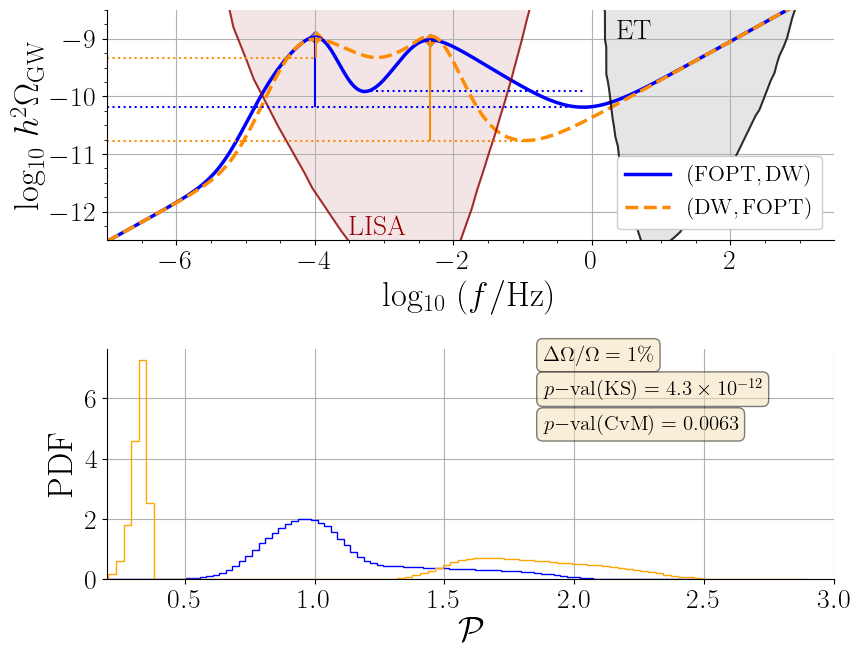

In [20]:
# Let us make some cool plots
fig, axs = plt.subplots(2, 1, figsize=(9, 7), tight_layout=True)

##### Histograms (density=True to normalise integral to 1)
SIGSUM_PT = Signal1_sum.hist(bins=n_bins, density=True, color='blue',   histtype = 'step', ax=axs[1], range=plt_range_1)
SIGSUM_DW = Signal2_sum.hist(bins=n_bins, density=True, color='orange', histtype = 'step', ax=axs[1], range=plt_range_2)

##### Legend and axes for the histogram plot
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
axs[1].text(0.60, 0.95, r'$\Delta\Omega/\Omega = {}\%$'.format(int(perc*100)),transform=axs[1].transAxes, bbox=props, fontsize=15)
axs[1].text(0.60, 0.80, '$p$$-$$\mathrm{{val}} (\mathrm{{KS}}) = {a}$'.format(a=latex_float(p_value_KS)), transform=axs[1].transAxes, bbox=props, fontsize=15)
axs[1].text(0.60, 0.65, '$p$$-$$\mathrm{{val}} (\mathrm{{CvM}}) = {a}$'.format(a=latex_float(p_value_CVM)), transform=axs[1].transAxes, bbox=props, fontsize=15)
axs[1].set_xlabel(r'$\mathcal{P}$', fontsize=25)  
axs[1].set_ylabel(r'$\mathrm{PDF}$', fontsize=25)

##### x-axis limits
axs[1].set_xlim(0.2,3.0)

##### SGWB spectrum (backgroud parameters are fixed to their central values)
log10_h2Gal  = -7.85
log10_h2Ext  = -12.38
alphaExt     = 2/3
alphaGal     = 7/3
Back         = hOm_ExtGW(f_prom,log10_h2Ext,alphaExt) + hOm_GalGW(f_prom,log10_h2Gal,alphaGal)

##### GW curves
Om_Full1 = np.log10(hOm_PT_peak1 + hOm_DW_peak2 + Back)
Om_Full2 = np.log10(hOm_DW_peak1 + hOm_PT_peak2 + Back)
axs[0].plot(np.log10(f_prom), Om_Full1 ,'-',  color='blue',       linewidth=2.5, label=r'$\mathrm{(FOPT,DW)}$')
axs[0].plot(np.log10(f_prom), Om_Full2 ,'--', color='darkorange', linewidth=2.5, label=r'$\mathrm{(DW,FOPT)}$')
axs[0].legend(fontsize=16,loc='lower right')

##### GW experiments
fpeak  = [np.log10(Data_LISA['fpeak']),np.log10(Data_ET['fpeak'])]
Ompeak = [np.log10(Data_LISA['Ompeak']),np.log10(Data_ET['Ompeak'])]
labels = [r'$\mathrm{LISA}$',r'$\mathrm{ET}$']
colors = ['#920000','black']

for a in zip(fpeak,Ompeak,labels,colors):
    axs[0].plot(a[0], a[1], '-',label=a[2], color=a[3], rasterized=True, alpha=0.8)
    axs[0].fill_between(a[0], a[1], 1e-4*np.ones(len(a[0])), alpha=0.1, color=a[3], rasterized=True)
axs[0].text(x=-3.5,y=-12.4,s=r"$\mathrm{LISA}$",color='#920000')
axs[0].text(x=0.37,y=-9.0,s=r"$\mathrm{ET}$",color='black')

##### Prominence lines
peaks1, _        = find_peaks(Om_Full1, distance=1)
prominences_Sig1 = peak_prominences(Om_Full1, peaks1)[0]
contour_heights  = Om_Full1[peaks1] - prominences_Sig1
axs[0].scatter(np.log10(f_prom)[peaks1],Om_Full1[peaks1],marker='D',color='blue')
axs[0].vlines(x=np.log10(f_prom)[peaks1], ymin=contour_heights, ymax=Om_Full1[peaks1],color='blue',linestyle='solid',zorder=100)
axs[0].hlines(y=contour_heights,xmin=np.log10(f_prom)[peak_prominences(Om_Full1, peaks1)[1]], xmax=np.log10(f_prom)[peak_prominences(Om_Full1, peaks1)[2]], color='blue',linestyle=':', alpha=1,linewidth=1.5)    

peaks2, _        = find_peaks(Om_Full2, distance=1)
prominences_Sig2 = peak_prominences(Om_Full2, peaks2)[0]
contour_heights  = Om_Full2[peaks2] - prominences_Sig2
axs[0].scatter(np.log10(f_prom)[peaks2],Om_Full1[peaks2],marker='D',color='darkorange')
axs[0].vlines(x=np.log10(f_prom)[peaks2], ymin=contour_heights, ymax=Om_Full1[peaks2],color='darkorange',linestyle='solid',zorder=100)
axs[0].hlines(y=contour_heights,xmin=np.log10(f_prom)[peak_prominences(Om_Full2, peaks2)[1]], xmax=np.log10(f_prom)[peak_prominences(Om_Full2, peaks1)[2]], color='darkorange',linestyle=':', alpha=1,linewidth=1.5)    

##### Axis labels and grid
axs[0].set_ylim(-12.5,-8.5)
axs[0].set_xlim(np.log10(1e-7), np.log10(f_ET_max))
axs[0].set_xlabel(r'$\mathrm{log_{10}}~(f/\mathrm{Hz})$',fontsize=25)
axs[0].set_ylabel(r'$\mathrm{log_{10}}~h^2 \Omega_\mathrm{GW}$',fontsize=25)
axs[0].grid()

##### Extra ticks
axs[0].xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
axs[0].yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))

plt.savefig('./Plots/Case_B.pdf',dpi=125.)


